# BÁO CÁO PHÂN TÍCH DỮ LIỆU & KẾ HOẠCH XỬ LÝ HÀNG TỒN ĐỌNG LOST & FOUND (L&F)
## Đợt Đồng Kiểm & Xử Lý Kho HCM (Tiếp Nhận Trước Ngày 25/09/2023)

---

### Cấu Trúc Báo Cáo & Notebook
1. **Phần 1**: Data Audit, Làm sạch & Chuẩn hóa Dữ liệu
2. **Phần 2**: Phân loại & Xây dựng Ma trận Xử lý theo Policy (SOP & TTLT 18)
3. **Phần 3**: Kế hoạch Tác chiến Xử lý Dứt điểm trong 7 Ngày Dương lịch (Capacity Planning)
4. **Phần 4**: Streamlit BI Dashboard Giám sát & Tái sử dụng (Standalone Web App: app.py)
5. **Phần 5**: Đề xuất Tự động hóa & Cải tiến Quy trình Vận hành (Kèm Template nhập liệu chuẩn)

---
# PHẦN 1: DATA AUDIT & LÀM SẠCH DỮ LIỆU
## Quy Trình Điều Tra Dữ Liệu: Cách Phát Hiện Lỗi & Lý Do Ra Quyết Định



In [ ]:
import sys
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
from collections import Counter


plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

In [62]:
FILE_PATH = 'Test DA.xlsx'
xls = pd.ExcelFile(FILE_PATH)
target_sheet = 'HCM - Hàng GE, GBC trước ngày 2'

raw_df = pd.read_excel(xls, sheet_name=target_sheet)
raw_df.head(5)


,,ID,Tên hàng hóa,Ticket,Dịch vụ,Vị trí lưu trữ của COA,Phân loại hàng hóa (theo cột C),Note
0,2023-08-16 13:07:13,4934574,1 tai nghe và dây sạc cũ,462350510,HCM-GE,"THÙNG 01- BÌ SỐ 1, 18 ITEM","Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)",NaN
1,2023-08-16 13:33:20,6632493,1 tập hồ sơ hợp đồng,461937467,HCM-GE,"THÙNG 01- BÌ SỐ 1, 18 ITEM","Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)",NaN
2,2023-08-05 15:38:45,1999592,1 hợp đồng lao động,458514116,HCM-GE,"THÙNG 01- BÌ SỐ 1, 18 ITEM","Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)",NaN


### INSPECT 1: ĐIỀU TRA TIÊU ĐỀ CỘT

#### 1. Cách phát hiện lỗi (How i found it):
- Khi duyệt danh sách các cột qua `raw_df.columns`, tôi phát hiện phần tử đầu tiên là một chuỗi rỗng toàn khoảng trắng (`' '`).
- Tuy nhiên, khi in mẫu 5 dòng đầu tiên của cột này, dữ liệu bên dưới hoàn toàn là các mốc thời gian tiếp nhận tài sản (`2023-08-16 13:07:13`, `2023-08-16 13:33:20`...).

#### 2. Vì sao quyết định giải quyết theo cách này (Why i decided):
- **Phân tích rủi ro**: Nếu dev dùng các hàm tự động như `df.dropna(axis=1)` hoặc bỏ qua cột không tên, toàn bộ dữ liệu ngày tiếp nhận sẽ bị mất
- **Hệ quả**: Ngày tiếp nhận là căn cứ duy nhất để tính số ngày lưu kho (Aging) nhằm so khớp với thời hạn quy định (SLA 30 ngày cho GBC, 180 ngày cho GE). Mất cột này đồng nghĩa với việc không thể xác định món hàng nào còn hạn hay quá hạn.
- **Quyết định**: Đổi tên cột thành `raw_timestamp`, bảo toàn 100% dữ liệu gốc để xử lý ngày tháng ở bước tiếp theo.


In [63]:
# Code chứng minh Bước 1: Phát hiện cột khuyết tên
col0 = raw_df.columns[0]
print(f"Giá trị tên cột 0 (repr): {repr(col0)}")
print(f"Độ dài tên cột 0: {len(col0)} ký tự khoảng trắng")
print("Mẫu dữ liệu thực tế bên trong cột 0:")
print(raw_df[col0].head(3))

# Chuẩn hóa tên cột
df = raw_df.rename(columns={
    col0: 'raw_timestamp',
    'ID': 'item_id',
    'Tên hàng hóa': 'item_name',
    'Ticket': 'ticket_id',
    'Dịch vụ': 'service',
    'Vị trí lưu trữ của COA ': 'storage_location',
    'Phân loại hàng hóa (theo cột C)': 'raw_category',
    'Note': 'raw_note'
}).copy()


Giá trị tên cột 0 (repr): '                                                                        '
Độ dài tên cột 0: 72 ký tự khoảng trắng
Mẫu dữ liệu thực tế bên trong cột 0:
0    2023-08-16 13:07:13
1    2023-08-16 13:33:20
2    2023-08-05 15:38:45
Name:                                                                         , dtype: object


### INSPECT 2: ĐIỀU TRA ĐỊNH DẠNG NGÀY, LỖI `#REF!` VÀ BẪY `DD/MM/YYYY`

#### 1. Cách phát hiện lỗi (How i found it):
- Khi kiểm tra kiểu dữ liệu trong cột thời gian, tôi thấy có sự hỗn tạp: 1,093 cell có kiểu `datetime`, nhưng có tới 547 cell là chuỗi văn bản (`str`) dạng `"25/07/2022 13:17:12"` hoặc `"31/08/2022"`.
- Đặc biệt, tôi phát hiện lỗi công thức Excel: cell chứa giá trị `'#REF!'` do file Excel bị lỗi tham chiếu trong các hàm như VLOOKUP.
- **Bẫy định dạng**: Nếu gọi `pd.to_datetime(df['raw_timestamp'])` mặc định không có cờ chỉ định, Python sẽ hiểu theo format `MM/DD/YYYY`. Khi đó một ngày như `"04/11/2022"` (ngày 4 tháng 11) sẽ bị đảo lộn thành `"11/04/2022"` (ngày 11 tháng 4), làm sai lệch hoàn toàn tuổi lưu kho của kiện hàng!

#### 2. Vì sao quyết định giải quyết theo cách này (Why i decided):
- **Với bẫy định dạng**: Bắt buộc dùng `dayfirst=True` để khớp với quy chuẩn nhập liệu hành chính tại Việt Nam (`DD/MM/YYYY`).
- **Với lỗi `#REF!` và dòng khuyết ngày (58 dòng)**:
  - *Tại sao không drop?* Vì các kiện hàng này có thật trong kho, đang chiếm chỗ và cần kiểm đếm.
  - *Xử lý thời hạn thế nào?* Đề bài xác định rõ: Toàn bộ danh sách này là hàng tiếp nhận **trước ngày 25/09/2023**. Hầu hết các dòng có `#REF!` đều nằm xen kẽ giữa các lô hàng từ năm 2021–2022. Do đó, việc gán trạng thái **Quá hạn** cho các dòng khuyết ngày là hoàn toàn an toàn và phản ánh đúng thực tế tồn đọng.


In [ ]:
# Code chứng minh Bước 2: Phát hiện kiểu dữ liệu & #REF!

types_counter = Counter(df['raw_timestamp'].apply(lambda x: type(x).__name__))

# Tìm các cell chứa lỗi #REF! hoặc định dạng lạ
ref_rows = df[df['raw_timestamp'].astype(str).str.contains('#REF!', na=False)]

# Hàm chuẩn hóa
def clean_timestamp(val):
    if pd.isna(val) or val == '#REF!' or str(val).strip() == '':
        return pd.NaT
    if isinstance(val, (pd.Timestamp, datetime)):
        return pd.to_datetime(val)
    val_str = str(val).strip()
    try:
        return pd.to_datetime(val_str, dayfirst=True)
    except:
        return pd.NaT

df['cleaned_date'] = df['raw_timestamp'].apply(clean_timestamp)


### INSPECT 3: ĐIỀU TRA "HÀNG MA" THIẾU ID & ID = `"không có"` NHƯNG CHỨA TÀI SẢN GIÁ TRỊ CAO

#### 1. Cách phát hiện lỗi (How i found it):
- Khi chạy check null `df['item_id'].isnull().sum()`, tôi thấy có 6 dòng NaN.
- Tiếp tục kiểm tra các giá trị chuỗi qua `df['item_id'].value_counts()`, phát hiện giá trị `"không có"` xuất hiện 6 lần.
- Tổng cộng có 12 dòng dữ liệu bị khuyết ID hợp lệ. tôi tiến hành "mổ xẻ" chi tiết nội dung 12 dòng này.

#### 2. Những phát hiện gây sốc trong 12 dòng này:
- **Cụm 6 dòng NaN (Dòng 1399–1404) tại `THÙNG 30 - BÌ 2`**:
  - `1 điện thoại iphone màu vàng gold, imei 01388 300 5808724`
  - `1 điện thoại iphone đen`
  - `1 bóp xanh ngọc: 1 CMND tên Châu Phước Sang, 4,000 VNĐ, thẻ học sinh...`
  - `1 bóp màu xanh: 1 CMND tên Nguyễn Viết Dũng, thẻ VCB...`
  - `1 bóp nâu: 1 CCCD Nguyễn Khôi Nguyên, 1 thẻ BHYT, 1 thẻ sĩ quan...`
  - `1 cái bóp LV màu, 1 thẻ Starbucks`
- **Cụm 6 dòng ID `"không có"` (Dòng 1542, 1549, 1550, 1609–1611)**:
  - `1 nồi chiên cỡ lớn` (Air fryer - thiết bị điện gia dụng cồng kềnh, giá trị cao)
  - `1 bịch đựng thuốc nhiều loại` (Dược phẩm y tế - rủi ro kiểm soát hóa chất)
  - `1 chai rượu voka đang dùng` (Đồ uống có cồn)

#### 3. Vì sao quyết định giải quyết theo cách này (Why i decided):
- **Hậu quả nếu xóa**: Nếu xóa 12 dòng này sẽ xóa sổ khỏi hệ thống **2 chiếc điện thoại iPhone, 3 chiếc ví chứa CMND/CCCD/tiền mặt, 1 nồi chiên không dầu lớn và thuốc y tế**! Trong thực tế kho bãi, hành động này tương đương với làm mất dấu vết tài sản, gây thất thoát vật chất và vi phạm nghiêm trọng quy định pháp luật.
- **Quyết định**: **GIỮ LẠI 100% CẢ 12 DÒNG NÀY**. Hệ thống tự động cấp phát mã định danh vận hành giả định (`MANUAL-ITEM-XXXX`) để tổ đồng kiểm in nhãn dán trực tiếp lên kiện hàng vật lý tại kho.

In [65]:
# Code chứng minh Bước 3: Vạch trần 12 dòng tài sản thiếu ID
null_ids = df[df['item_id'].isnull()]
khong_co_ids = df[df['item_id'].astype(str).str.strip().str.lower() == 'không có']

print(f"1. Số dòng ID là NaN: {len(null_ids)}")
print(f"2. Số dòng ID là 'không có': {len(khong_co_ids)}")

print("\nChi tiết các tài sản trong 6 dòng ID là NaN (THÙNG 30 - BÌ 2):")
for _, r in null_ids.iterrows():
    print(f"  - [{r['storage_location']}] {repr(r['item_name'][:70])}")

print("\nChi tiết các tài sản trong 6 dòng ID là 'không có':")
for _, r in khong_co_ids.iterrows():
    print(f"  - [{r['storage_location']}] {repr(r['item_name'][:70])}")


1. Số dòng ID là NaN: 6
2. Số dòng ID là 'không có': 6

Chi tiết các tài sản trong 6 dòng ID là NaN (THÙNG 30 - BÌ 2):
  - [THÙNG 30 - BÌ 2] '1 cái bóp LV màu \n1 thẻ Starbucks'
  - [THÙNG 30 - BÌ 2] '1 bóp màu xanh ngọc\n1 CMND tên Châu Phước Sang số 366354602\n1 thẻ học '
  - [THÙNG 30 - BÌ 2] '1 bóp màu xanh \n1 CMND tên Nguyễn Viết Dũng số 272 477 432\n1 thẻ VCB N'
  - [THÙNG 30 - BÌ 2] '1 điện thoại iphone màu vàng gold\nimei 01388 300 5808724'
  - [THÙNG 30 - BÌ 2] '1 điện thoại iphone đen '
  - [THÙNG 30 - BÌ 2] '1 bóp nâu\n1 CCCD Nguyễn Khôi Nguyên số 0792 01004 130 \n1 thẻ BHYT\n1 th'

Chi tiết các tài sản trong 6 dòng ID là 'không có':
  - [BÌ 54 -LẺ] 'Bịch nilong đen : 6 chai suối chưa khui & 1 băng keo trong đã dùng & 1'
  - [nan] '1 balo đen chứa 1 bộ quần áo đã dùng'
  - [nan] '1 túi vải đen gồm 1 quần đùi nam mới & 1 quần jean đã dùng & 1 chai rư'
  - [TRONG KHO LÝ THƯỜNG KIỆT ] '1 nồi chiên cỡ lớn'
  - [TRONG KHO LÝ THƯỜNG KIỆT ] '1 bịch đựng thuốc nhiều loại'
  - [TRON

### INSPECT 4: ĐIỀU TRA TRÙNG ID VÀ TICKET

#### 1. Cách phát hiện lỗi (How i found it):
- Khi thống kê tần suất xuất hiện `df['item_id'].value_counts()`, ID `5253492` xuất hiện tới **14 lần**, và Ticket `435261798` xuất hiện tới **12 lần**.
- Khi lọc toàn bộ các dòng mang ID `5253492`, tôi nhận thấy các kiện hàng nằm rải rác ở khắp các vị trí kho khác nhau: `THÙNG 1 - BÌ 3`, `BAO 1 - BÌ 3`, `Bao 4`, `BAO 5 - BÌ 2`, `BAO 9 - BÌ 1`, `BAO 12 - BÌ 3`, `TRONG KHO LÝ THƯỜNG KIỆT`...
- Tên hàng cũng rất khác nhau: Dòng là `"1 cái nón màu hồng"`, dòng là `"1 cái ví nam"`, dòng là `"1 thuốc lá điện tử"`, và nhiều dòng là `"1 chìa khóa"`.

#### 2. Vì sao quyết định giải quyết theo cách này (Why i decided):
- **Bản chất nghiệp vụ**: Nhân viên kho khi nhặt được chìa khóa lẻ rơi ngoài bãi xe hoặc hàng không có ticket thường có thói quen copy một mã ticket/ID cũ sẵn có trên file để "cho qua chuyện" thay vì tạo ticket mới hoặc lỗi đánh máy khi cố gắng tạo ticket mới hoặc là gom chung vào 1 ticket cho nhanh.
- **Rủi ro nếu xử lý sai**: Nếu chúng ta deduplicate theo `df.drop_duplicates(subset=['item_id'])`, Python sẽ xóa 13 dòng và chỉ giữ lại 1 dòng duy nhất! Hậu quả là 13 kiện hàng (nón, ví tiền, chìa khóa tại các bao khác) sẽ bị "bốc hơi" khỏi danh sách kiểm đếm.
- **Quyết định**: cần phân biệt rõ:
  - Nếu trùng ID/Ticket nhưng **khác vị trí kho hoặc khác tên hàng**: GIỮ LẠI (đây là các món hàng vật lý khác nhau dùng chung mã giữ chỗ).
  - Nếu trùng cả `(item_id, ticket_id, item_name, storage_location)`: LOẠI BỎ (đây mới là nhập liệu đúp do click nhầm).


In [81]:
# Code chứng minh Bước 4: Khảo sát mã giữ chỗ 5253492
sample_dummy = df[df['item_id'].astype(str).str.contains('5253492', na=False)]
print(f"Tổng số dòng mang ID 5253492: {len(sample_dummy)}")
print("Phân bố vị trí và tên hàng của mã giữ chỗ này:")
sample_dummy[['storage_location', 'item_name', 'ticket_id']].head(6)


Tổng số dòng mang ID 5253492: 14
Phân bố vị trí và tên hàng của mã giữ chỗ này:


,storage_location,item_name,ticket_id
603,THÙNG 1- BÌ 3 - GC,1 chìa khóa,435261798
672,BAO 1 - BÌ 3 ( 8 ITEM - GBC ),1 chìa khóa,435261798
674,BAO 1 - BÌ 3 ( 8 ITEM - GBC ),1 cái nón màu hồng,435261798
707,BAO 2 (128-152),1 cái ví nam (125k + 3 thẻ taxi Mai Linh),435261798
726,Bao 4,1 chìa khóa,435261798
735,BAO 5 - BÌ 2,1 chìa khóa,435261798


### INSPECT 5: "HÀNG ẢO" DO COPY CHUYỂN KHO HUB GÒ VẤP

#### 1. Cách phát hiện lỗi (How i found it):
- Khi khảo sát các dòng bị khuyết phân loại `df[df['raw_category'].isna()]`, tôi thấy xuất hiện đúng 5 dòng tại vị trí cuối cùng của bảng (dòng 1639–1643).
- Lần ngược lại toàn bộ thông tin của 5 dòng này, tôi so sánh chéo với các dòng phía trên và phát hiện sự trùng hợp 100%:
  - Dòng 1639 (`4344905`, Ticket `251361271`, *"1 máy may để bàn mini"*) == Dòng 1618.
  - Dòng 1640 (`1927193`, Ticket `256026613`, *"4 tượng Thạch cao"*) == Dòng 1624.
  - Dòng 1641 (`2850411`, Ticket `257630180`, *"1 cái Quần Tây Xám"*) == Dòng 1627.
  - Dòng 1642 (`5391738`, Ticket `261723154`, *"1 Hộp quà tết,"*) == Dòng 1629.
  - Dòng 1643 (`4920424`, Ticket `266298154`, *"4 hợp kỷ niệm chương"*) == Dòng 1631.
- **Dấu vết bất thường**: Cột Note của 5 dòng cuối cùng này ghi rõ: *"Hàng Hubs Gò Vấp chuyển về"*, cột Dịch vụ bị tách thành `HCM-GE` và `HCM-GBC`, và cột Category bị bỏ quên không gán dữ liệu.

#### 2. Vì sao quyết định giải quyết theo cách này (Why i decided):
- **Phân tích nghiệp vụ chuyển kho**: Khi Hub Gò Vấp bàn giao lô hàng tồn về Kho trung tâm Lý Thường Kiệt, nhân viên lập biên bản tiếp nhận đã copy 5 dòng này dán thêm vào cuối file tổng mà **quên xóa bản ghi cũ đã có sẵn từ trước** trong kho.
- **Rủi ro**: Trong kho Lý Thường Kiệt chỉ có **DUY NHẤT 1 chiếc máy may mini** và **1 hộp quà tết**. Nếu giữ cả hai bản ghi, danh sách kiểm đếm sẽ yêu cầu thủ kho phải tìm ra 2 chiếc máy may mini (gây ra tình trạng "hàng ảo").
- **Quyết định**: **LOẠI BỎ (Drop)** 5 dòng copy thừa ở cuối bảng (1639–1643) để trả về đúng số lượng vật lý thực tế.


In [67]:
# Code chứng minh Bước 5: So sánh đối đầu 5 cặp dòng trùng lặp do chuyển kho
tail_indices = [1639, 1640, 1641, 1642, 1643]
orig_indices = [1618, 1624, 1627, 1629, 1631]

comparison = []
for orig, tail in zip(orig_indices, tail_indices):
    comparison.append({
        "ID": df.loc[orig, 'item_id'],
        "Tên hàng hóa": df.loc[orig, 'item_name'],
        "Ticket": df.loc[orig, 'ticket_id'],
        "Bản ghi gốc (Dòng {})".format(orig): f"Dịch vụ: {df.loc[orig, 'service']} | Note: {df.loc[orig, 'raw_note']}",
        "Bản ghi copy đuôi (Dòng {})".format(tail): f"Dịch vụ: {df.loc[tail, 'service']} | Note: {df.loc[tail, 'raw_note']}"
    })
pd.DataFrame(comparison)


,ID,Tên hàng hóa,Ticket,Bản ghi gốc (Dòng 1618),Bản ghi copy đuôi (Dòng 1639),Bản ghi gốc (Dòng 1624),Bản ghi copy đuôi (Dòng 1640),Bản ghi gốc (Dòng 1627),Bản ghi copy đuôi (Dòng 1641),Bản ghi gốc (Dòng 1629),Bản ghi copy đuôi (Dòng 1642),Bản ghi gốc (Dòng 1631),Bản ghi copy đuôi (Dòng 1643)
0,4344905,1 máy may để bàn mini,251361271,Dịch vụ: HCM-GBC | Note: Hàng Hubs Gò Vấp chuyển về,Dịch vụ: HCM-GE | Note: Hàng Hubs Gò Vấp chuyển về,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1927193,4 tượng Thạch cao,256026613,NaN,NaN,Dịch vụ: HCM-GBC | Note: Hàng Hubs Gò Vấp chuyển về,Dịch vụ: HCM-GE | Note: Hàng Hubs Gò Vấp chuyển về,NaN,NaN,NaN,NaN,NaN,NaN
2,2850411,1 cái Quần Tây Xám,257630180,NaN,NaN,NaN,NaN,Dịch vụ: HCM-GBC | Note: Hàng Hubs Gò Vấp chuyển về,Dịch vụ: HCM-GE | Note: Hàng Hubs Gò Vấp chuyển về,NaN,NaN,NaN,NaN
3,5391738,"1 Hộp quà tết,",261723154,NaN,NaN,NaN,NaN,NaN,NaN,Dịch vụ: HCM-GBC | Note: Hàng Hubs Gò Vấp chuyển về,Dịch vụ: HCM-GE | Note: Hàng Hubs Gò Vấp chuyển về,NaN,NaN
4,4920424,4 hợp kỷ niệm chương,266298154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dịch vụ: HCM-GBC | Note: Hàng Hubs Gò Vấp chuyển về,Dịch vụ: HCM-GE | Note: Hàng Hubs Gò Vấp chuyển về


### INSPECT 6: SAI LỆCH SỐ TRONG SHEET BÁO CÁO CŨ

#### 1. Cách phát hiện lỗi (How i found it):
- Sheet `Báo cáo  HCM - Hàng GE, GBC trư` trong file Excel gốc ghi nhận chỉ số `Grand Total = 1464` (sử dụng hàm `COUNTUNIQUE of ID` trong Excel Pivot Table).
- Khi tôi kiểm tra tổng số dòng thực tế là **1,644 dòng**, chênh lệch lên tới **180 dòng**.

#### 2. Troubleshoot nguyên nhân sai lệch của Pivot Table:
1. **Gom 6 món có ID `"không có"` làm một**: Pivot Table xem chuỗi văn bản `"không có"` là một mã ID duy nhất => 6 món hàng khác nhau (nồi chiên lớn, thuốc tây, vodka...) bị đếm thành 1 món
2. **Bỏ qua hoàn toàn các dòng NaN**: 6 dòng tại `THÙNG 30 - BÌ 2` bị bỏ quên hoàn toàn trong Pivot Table (khiến iPhone, CCCD, ví tiền không được tính vào báo cáo).
3. **Gom các món hàng khác nhau dùng chung ID giữ chỗ**: 14 món hàng độc lập mang ID `5253492` chỉ được Pivot Table đếm là 1 món.

#### 3. Vì sao quyết định giải quyết theo cách này (Why i decided):
- **Thực tế vận hành**: Tổng số kiện hàng vật lý thực tế cần xử lý là **1,635 kiện**. Nếu cấp quản lý chỉ chuẩn bị nhân lực, bao bì và xe chuyên chở cho 1,464 món thì chiến dịch 7 ngày chắc chắn sẽ bị quá tải và thất bại!


In [82]:
# Code chứng minh Bước 6: Tái hiện sự sai lệch của Pivot Table cũ từ sheet Báo cáo
bc_sheet = [s for s in xls.sheet_names if 'Báo cáo' in s][0]
df_bc_old = pd.read_excel(xls, sheet_name=bc_sheet)
excel_pivot_count = int(df_bc_old.iloc[-1, -1])  # Tự động lấy Grand Total (1,464) từ file Excel
actual_rows = len(df)
raw_unique_ids = df['item_id'].dropna().nunique()

# Dự kiến số kiện hàng vật lý sau khi khử trùng lặp kỹ thuật và chuyển kho
prospective_clean_parcels = len(df) - (int(df.duplicated().sum()) + len(tail_indices) + 2)

print(f"1. Báo cáo cũ ghi nhận (sheet '{bc_sheet}'): {excel_pivot_count:,}")
print(f"2. Số Unique ID thực tế nếu tính bằng pandas (loại NaN): {raw_unique_ids:,}")
print(f"3. Số kiện hàng vật lý thực tế cần quản lý sau làm sạch: {prospective_clean_parcels:,}")
print(f"-> Sự chênh lệch thiếu hụt: {prospective_clean_parcels - excel_pivot_count:,} kiện hàng bị bỏ quên ngoài sổ sách!")


1. Báo cáo cũ ghi nhận (sheet 'Báo cáo  HCM - Hàng GE, GBC trư'): 1,464
2. Số Unique ID thực tế nếu tính bằng pandas (loại NaN): 1,481
3. Số kiện hàng vật lý thực tế cần quản lý sau làm sạch: 1,635
-> Sự chênh lệch thiếu hụt: 171 kiện hàng bị bỏ quên ngoài sổ sách!


### LÀM SẠCH DỮ LIỆU

In [69]:
# Loại bỏ 2 dòng trùng lặp 100% hoàn toàn
df_clean = df.drop_duplicates().copy()

# Loại bỏ 5 dòng copy chuyển kho Gò Vấp ở cuối bảng
df_clean = df_clean.drop(index=[i for i in tail_indices if i in df_clean.index])

# Loại bỏ các dòng trùng lặp tuyệt đối cùng (item_id, ticket_id, item_name, storage_location)
dup_biz_mask = df_clean.duplicated(subset=['item_id', 'ticket_id', 'item_name', 'storage_location'], keep='first')
print(f"Số dòng trùng lặp thao tác cùng ID, Ticket, Tên, Vị trí kho bị loại: {dup_biz_mask.sum()}")
df_clean = df_clean[~dup_biz_mask].copy()

# Cấp mã Synthetic ID cho hàng thiếu ID để bảo toàn kiểm đếm vật lý
def assign_operational_id(row, idx):
    raw_id = str(row['item_id']).strip().lower()
    if pd.isna(row['item_id']) or raw_id in ['nan', 'không có', 'none', '']:
        return f"MANUAL-ITEM-{idx:04d}"
    try:
        return str(int(float(raw_id)))
    except:
        return str(row['item_id']).strip()

df_clean['system_item_id'] = [assign_operational_id(row, i) for i, (_, row) in enumerate(df_clean.iterrows(), start=1)]

# Chuẩn hóa danh mục phân loại
def standardize_category(row):
    cat = str(row['raw_category']).strip()
    name = str(row['item_name']).strip().lower()
    
    if cat in ['nan', '', 'None']:
        if 'máy may' in name:
            return 'Thiết bị điện tử có giá'
        elif 'quà tết' in name or 'thực phẩm' in name:
            return 'Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)'
        return 'Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)'
    
    if 'Thiết bị điện tử' in cat:
        return 'Thiết bị điện tử có giá'
    elif 'Giấy tờ tùy thân' in cat or 'Tiền mặt' in cat:
        return 'Tiền mặt & giấy tờ cấp bởi CQCN'
    elif 'Thẻ Ngân hàng' in cat:
        return 'Thẻ Ngân hàng'
    elif 'Thuốc lá điện tử' in cat:
        return 'Thuốc lá điện tử'
    elif 'Hàng hóa hàng ngày' in cat:
        return 'Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)'
    return cat

df_clean['standard_category'] = df_clean.apply(standardize_category, axis=1)

print(f"Hoàn tất làm sạch! Số kiện hàng vật lý chuẩn xác: {len(df_clean)} kiện.")


Số dòng trùng lặp thao tác cùng ID, Ticket, Tên, Vị trí kho bị loại: 2
Hoàn tất làm sạch! Số kiện hàng vật lý chuẩn xác: 1635 kiện.


## Báo cáo Data Quality

In [83]:
# Báo cáo Data Quality issues tìm được
# Trùng lặp 100% tất cả các cột
n_exact_dups = int(df.duplicated().sum())

# Dòng copy chuyển kho Hub Gò Vấp ở cuối bảng
n_govap_tail_dups = len([i for i in tail_indices if i in df.index])

# Trùng lặp thao tác cùng (ID, Ticket, Tên hàng, Vị trí kho) sau khi đã drop exact & tail
df_dedup_step2 = df.drop_duplicates().drop(index=[i for i in tail_indices if i in df.index])
dup_biz_mask_calc = df_dedup_step2.duplicated(subset=['item_id', 'ticket_id', 'item_name', 'storage_location'], keep='first')
n_biz_dups = int(dup_biz_mask_calc.sum())

# Thiếu ID hợp lệ (NaN hoặc 'không có')
n_null_ids = int(df['item_id'].isna().sum())
n_khong_co_ids = int((df['item_id'].astype(str).str.strip().str.lower() == 'không có').sum())
n_missing_ids = n_null_ids + n_khong_co_ids

# Lỗi ngày tháng hoặc khuyết ngày tiếp nhận
n_date_errors = int(df['cleaned_date'].isna().sum())

# Khuyết danh mục phân loại ban đầu
n_cat_missing = int(df['raw_category'].isna().sum())

# Tổng số dòng loại bỏ và tổng số kiện giữ lại
total_dropped = n_exact_dups + n_govap_tail_dups + n_biz_dups

decision_log = pd.DataFrame([
    {
        "STT": 1,
        "Loại lỗi / Bất thường dữ liệu": "Trùng lặp 100% tất cả các cột",
        "Số lượng thực tế (dòng)": n_exact_dups,
        "Tỷ lệ tác động": f"{n_exact_dups / len(df):.2%}",
        "Hành động xử lý": "LOẠI BỎ (Drop)",
        "Lý do kỹ thuật & Nghiệp vụ": (
            f"Dữ liệu bị trùng lặp kỹ thuật hoàn toàn do double submission. "
            f"Loại bỏ đúng {n_exact_dups} dòng để tránh đếm ảo 1 món hàng thành 2."
        )
    },
    {
        "STT": 2,
        "Loại lỗi / Bất thường dữ liệu": "Copy-paste thừa khi chuyển kho Hub Gò Vấp",
        "Số lượng thực tế (dòng)": n_govap_tail_dups,
        "Tỷ lệ tác động": f"{n_govap_tail_dups / len(df):.2%}",
        "Hành động xử lý": "LOẠI BỎ (Drop)",
        "Lý do kỹ thuật & Nghiệp vụ": (
            f"Biên bản bàn giao từ Hub Gò Vấp dán đè {n_govap_tail_dups} dòng đã có sẵn bản ghi gốc tại kho Lý Thường Kiệt. "
            f"Loại bỏ để triệt tiêu 'hàng ảo' (phantom inventory), tránh thủ kho đi tìm 2 máy may/hộp quà trong khi chỉ có 1."
        )
    },
    {
        "STT": 3,
        "Loại lỗi / Bất thường dữ liệu": "Trùng lặp thao tác cùng (ID, Ticket, Tên hàng, Vị trí kho)",
        "Số lượng thực tế (dòng)": n_biz_dups,
        "Tỷ lệ tác động": f"{n_biz_dups / len(df):.2%}",
        "Hành động xử lý": "LOẠI BỎ (Drop)",
        "Lý do kỹ thuật & Nghiệp vụ": (
            f"Nhân viên kho nhập 2 lần cùng 1 món đồ trong cùng 1 bao/thùng (ví dụ cặp chìa khóa BAO 5 - BÌ 2). "
            f"Loại bỏ {n_biz_dups} dòng đúp thao tác."
        )
    },
    {
        "STT": 4,
        "Loại lỗi / Bất thường dữ liệu": "Thiếu mã định danh hợp lệ (NaN hoặc 'không có')",
        "Số lượng thực tế (dòng)": n_missing_ids,
        "Tỷ lệ tác động": f"{n_missing_ids / len(df):.2%}",
        "Hành động xử lý": "GIỮ LẠI (Cấp mã Synthetic ID)",
        "Lý do kỹ thuật & Nghiệp vụ": (
            f"Gồm {n_null_ids} dòng NaN (iPhone, CCCD, ví tiền) và {n_khong_co_ids} dòng 'không có' (nồi chiên lớn, vodka, thuốc y tế). "
            f"TUYỆT ĐỐI KHÔNG XÓA vì đây là tài sản vật lý có thật đang chiếm chỗ; tự động cấp mã MANUAL-ITEM để kiểm đếm."
        )
    },
    {
        "STT": 5,
        "Loại lỗi / Bất thường dữ liệu": "Lỗi công thức #REF! hoặc khuyết ngày tiếp nhận",
        "Số lượng thực tế (dòng)": n_date_errors,
        "Tỷ lệ tác động": f"{n_date_errors / len(df):.2%}",
        "Hành động xử lý": "GIỮ LẠI (Gán mặc định Quá hạn)",
        "Lý do kỹ thuật & Nghiệp vụ": (
            f"Toàn bộ lô hàng tiếp nhận trước 25/09/2023. {n_date_errors} dòng khuyết ngày đều là hàng tồn đọng lâu năm "
            f"(xen kẽ năm 2021-2022) nên an toàn gán Quá hạn để xử lý dứt điểm."
        )
    },
    {
        "STT": 6,
        "Loại lỗi / Bất thường dữ liệu": "Khuyết danh mục phân loại ban đầu (raw_category is Null)",
        "Số lượng thực tế (dòng)": n_cat_missing,
        "Tỷ lệ tác động": f"{n_cat_missing / len(df):.2%}",
        "Hành động xử lý": "GIỮ LẠI (Impute bằng Tên hàng)",
        "Lý do kỹ thuật & Nghiệp vụ": (
            f"Tự động điền phân loại cho {n_cat_missing} dòng dựa trên keyword tên hàng ('máy may' -> Điện tử, 'quà tết' -> Tiêu dùng) "
            f"để bảo đảm 100% kiện hàng có chính sách xử lý."
        )
    }
])
display(decision_log)

print(f"\n--- DATA RECONCILIATION ---")
print(f"• Tổng số dòng dữ liệu thô ban đầu: {len(df):,} dòng (100.0%)")
print(f"• Tổng số dòng loại bỏ (Drop): {total_dropped:,} dòng ({total_dropped / len(df):.2%}) "
      f"[Gồm: {n_exact_dups} trùng 100% + {n_govap_tail_dups} chuyển kho Gò Vấp + {n_biz_dups} trùng thao tác]")
print(f"• Tổng số kiện hàng vật lý thực tế giữ lại: {len(df_clean):,} kiện ({len(df_clean) / len(df):.2%})")
print(f"• Kiểm tra tính toàn vẹn (Checksum Integrity): {len(df)} - {total_dropped} == {len(df_clean)} -> {len(df) - total_dropped == len(df_clean)}")


,STT,Loại lỗi / Bất thường dữ liệu,Số lượng thực tế (dòng),Tỷ lệ tác động,Hành động xử lý,Lý do kỹ thuật & Nghiệp vụ
0,1,Trùng lặp 100% tất cả các cột,2,0.12%,LOẠI BỎ (Drop),Dữ liệu bị trùng lặp kỹ thuật hoàn toàn do double submission. Loại bỏ đúng 2 dòng để tránh đếm ả...
1,2,Copy-paste thừa khi chuyển kho Hub Gò Vấp,5,0.30%,LOẠI BỎ (Drop),Biên bản bàn giao từ Hub Gò Vấp dán đè 5 dòng đã có sẵn bản ghi gốc tại kho Lý Thường Kiệt. Loại...
2,3,"Trùng lặp thao tác cùng (ID, Ticket, Tên hàng, Vị trí kho)",2,0.12%,LOẠI BỎ (Drop),Nhân viên kho nhập 2 lần cùng 1 món đồ trong cùng 1 bao/thùng (ví dụ cặp chìa khóa BAO 5 - BÌ 2)...
3,4,Thiếu mã định danh hợp lệ (NaN hoặc 'không có'),12,0.73%,GIỮ LẠI (Cấp mã Synthetic ID),"Gồm 6 dòng NaN (iPhone, CCCD, ví tiền) và 6 dòng 'không có' (nồi chiên lớn, vodka, thuốc y tế). ..."
4,5,Lỗi công thức #REF! hoặc khuyết ngày tiếp nhận,58,3.53%,GIỮ LẠI (Gán mặc định Quá hạn),Toàn bộ lô hàng tiếp nhận trước 25/09/2023. 58 dòng khuyết ngày đều là hàng tồn đọng lâu năm (xe...
5,6,Khuyết danh mục phân loại ban đầu (raw_category is Null),5,0.30%,GIỮ LẠI (Impute bằng Tên hàng),"Tự động điền phân loại cho 5 dòng dựa trên keyword tên hàng ('máy may' -> Điện tử, 'quà tết' -> ..."



--- DATA RECONCILIATION ---
• Tổng số dòng dữ liệu thô ban đầu: 1,644 dòng (100.0%)
• Tổng số dòng loại bỏ (Drop): 9 dòng (0.55%) [Gồm: 2 trùng 100% + 5 chuyển kho Gò Vấp + 2 trùng thao tác]
• Tổng số kiện hàng vật lý thực tế giữ lại: 1,635 kiện (99.45%)
• Kiểm tra tính toàn vẹn (Checksum Integrity): 1644 - 9 == 1635 -> True


In [71]:
# Bảng Tổng Hợp Đếm Distinct Items
distinct_summary = pd.DataFrame([
    {
        "Cấp độ thống kê": "1. Tổng số dòng dữ liệu thô (Raw Records)",
        "Số lượng thực tế": len(raw_df),
        "Phương pháp trích xuất": "len(raw_df)",
        "Ý nghĩa thực tiễn & Cảnh báo": "Bao gồm cả dòng rác, trùng lặp và copy lỗi khi chuyển kho."
    },
    {
        "Cấp độ thống kê": "2. Số lượng kiện hàng vật lý thực tế (Cleaned Parcels)",
        "Số lượng thực tế": len(df_clean),
        "Phương pháp trích xuất": "len(df_clean)",
        "Ý nghĩa thực tiễn & Cảnh báo": "SỐ LƯỢNG CHUẨN: Số kiện hàng vật lý thực tế cần quản lý, kiểm đếm & thuê xe bốc dỡ."
    },
    {
        "Cấp độ thống kê": "3. Số Unique ID báo cáo cũ (Pivot Table sheet Báo cáo)",
        "Số lượng thực tế": excel_pivot_count,
        "Phương pháp trích xuất": f"Sheet '{bc_sheet}'.iloc[-1, -1]",
        "Ý nghĩa thực tiễn & Cảnh báo": f"BỊ SAI: Bỏ quên {len(df_clean) - excel_pivot_count} kiện hàng vật lý do gom mã giữ chỗ và bỏ sót hàng thiếu ID."
    },
    {
        "Cấp độ thống kê": "4. Số Unique System Item ID thực tế",
        "Số lượng thực tế": df_clean['system_item_id'].nunique(),
        "Phương pháp trích xuất": "df_clean['system_item_id'].nunique()",
        "Ý nghĩa thực tiễn & Cảnh báo": "Bao gồm cả các mã Synthetic ID (MANUAL-ITEM-XXXX) cấp phát cho hàng khuyết mã."
    },
    {
        "Cấp độ thống kê": "5. Số Unique Ticket ID (Mã chuyến xe / Đơn hàng)",
        "Số lượng thực tế": df_clean['ticket_id'].dropna().nunique(),
        "Phương pháp trích xuất": "df_clean['ticket_id'].dropna().nunique()",
        "Ý nghĩa thực tiễn & Cảnh báo": "Số chuyến xe / đơn hàng phát sinh tài sản thất lạc."
    }
])
display(distinct_summary)


,Cấp độ thống kê,Số lượng thực tế,Phương pháp trích xuất,Ý nghĩa thực tiễn & Cảnh báo
0,1. Tổng số dòng dữ liệu thô (Raw Records),1644,len(raw_df),"Bao gồm cả dòng rác, trùng lặp và copy lỗi khi chuyển kho."
1,2. Số lượng kiện hàng vật lý thực tế (Cleaned Parcels),1635,len(df_clean),"SỐ LƯỢNG CHUẨN: Số kiện hàng vật lý thực tế cần quản lý, kiểm đếm & thuê xe bốc dỡ."
2,3. Số Unique ID báo cáo cũ (Pivot Table sheet Báo cáo),1464,"Sheet 'Báo cáo HCM - Hàng GE, GBC trư'.iloc[-1, -1]",BỊ SAI: Bỏ quên 171 kiện hàng vật lý do gom mã giữ chỗ và bỏ sót hàng thiếu ID.
3,4. Số Unique System Item ID thực tế,1492,df_clean['system_item_id'].nunique(),Bao gồm cả các mã Synthetic ID (MANUAL-ITEM-XXXX) cấp phát cho hàng khuyết mã.
4,5. Số Unique Ticket ID (Mã chuyến xe / Đơn hàng),1415,df_clean['ticket_id'].dropna().nunique(),Số chuyến xe / đơn hàng phát sinh tài sản thất lạc.


---
# PHẦN 2: PHÂN LOẠI & KẾ HOẠCH XỬ LÝ THEO POLICY

### Căn cứ quy định:
1. **Dịch vụ Vận tải hành khách (GBC - GrabBike/GrabCar)**:
   - Thời hạn lưu trữ chuẩn: **30 ngày** (riêng thực phẩm tươi sống chỉ lưu 24h).
   - Hết 30 ngày: Công ty có quyền bán, làm từ thiện, tiêu hủy hoặc bàn giao CQNN.
   - Do toàn bộ hàng tiếp nhận trước **25/09/2023**, tính đến ngày review thì **100% hàng GBC đã quá hạn lưu trữ**.
2. **Dịch vụ Chuyển phát bưu gửi (GE - GrabExpress)**:
   - Căn cứ **Thông tư liên tịch 18/2015/TTLT-BTTTT-BTC** & SOP:
     - Công khai thông tin tối thiểu **3 tháng** (90 ngày) + Lưu giữ bưu gửi **6 tháng** (180 ngày).
     - Tổng thời gian lưu trữ tối thiểu trước khi xử lý dứt điểm: **T+180 ngày** (hoặc 9 tháng nếu tính từ lúc tiếp nhận).
     - Hàng tiếp nhận trước **25/03/2023** (> 180 ngày) -> **Quá hạn lưu trữ**, đủ điều kiện xử lý dứt điểm.
3. **Quy tắc phân loại hình thức xử lý**:
   - `Bàn giao CQNN`: Giấy tờ tùy thân (CMND, CCCD, GPLX), tiền mặt, thẻ ngân hàng. Lập biên bản theo **Phụ lục 4** TTLT 18.
   - `Thuê Vendor tiêu hủy`: Hàng tiêu dùng (quần áo, giày dép, mắt kính, sách vở...). Lập biên bản **Phụ lục 3** TTLT 18.
   - `Tiêu hủy / Thanh lý thiết bị điện tử`: Điện thoại, laptop, sạc... Phải xóa dữ liệu cá nhân, reset factory -> đề xuất thanh lý thu hồi chi phí hoặc thuê vendor hủy nếu hư hỏng.
   - `Tự tiêu hủy tại Hub`: Thuốc lá điện tử (hàng cấm/nhạy cảm) hoặc thực phẩm hư hỏng. Lập biên bản **Phụ lục 5** TTLT 18.


In [72]:
CUTOFF_DATE = pd.to_datetime('2023-09-25')

def evaluate_policy(row):
    service = str(row['service']).strip().upper()
    cat = row['standard_category']
    date = row['cleaned_date']
    
    # Tính số ngày lưu kho đến 25/09/2023
    if pd.isna(date):
        days_in_storage = 999
    else:
        days_in_storage = (CUTOFF_DATE - date).days
    
    # Aging Status
    if 'CQCN' in cat or 'Thẻ Ngân hàng' in cat:
        status = 'Cần gửi CQNN'
    else:
        if 'GBC' in service:
            status = 'Quá hạn' if days_in_storage >= 30 else 'Còn hạn'
        else:
            status = 'Quá hạn' if days_in_storage >= 180 else 'Còn hạn'
            
    # Disposal Action
    if 'CQCN' in cat or 'Thẻ Ngân hàng' in cat:
        disposal_action = 'Bàn giao CQNN / Ngân hàng'
        legal_form = 'Phụ lục 4 (TTLT 18)'
        responsible_pic = 'COA + Legal + FPS'
    elif 'Thuốc lá điện tử' in cat:
        disposal_action = 'Tự tiêu hủy tại Hub (Chất thải nguy hại)'
        legal_form = 'Biên bản tiêu hủy nội bộ'
        responsible_pic = 'FPS + COA'
    elif 'Thiết bị điện tử' in cat:
        disposal_action = 'Xóa dữ liệu & Thanh lý / Thuê Vendor hủy'
        legal_form = 'Phụ lục 3 (TTLT 18)'
        responsible_pic = 'GE + FPS + Procurement'
    else:
        disposal_action = 'Thuê Vendor tiêu hủy / Quyên góp'
        legal_form = 'Phụ lục 3 (TTLT 18)'
        responsible_pic = 'GE + FPS + Vendor'
        
    return pd.Series([days_in_storage, status, disposal_action, legal_form, responsible_pic],
                     index=['days_in_storage', 'aging_status', 'disposal_action', 'legal_form', 'responsible_pic'])

policy_eval = df_clean.apply(evaluate_policy, axis=1)
df_clean[['days_in_storage', 'aging_status', 'disposal_action', 'legal_form', 'responsible_pic']] = policy_eval

In [73]:
summary_pivot = pd.crosstab(
    index=[df_clean['service'], df_clean['standard_category']],
    columns=[df_clean['aging_status'], df_clean['disposal_action']],
    margins=True, margins_name='Tổng cộng'
)
summary_pivot

aging_status                                                                               Còn hạn                                                                                                Cần gửi CQNN                          Quá hạn                                                                                   Tổng cộng
disposal_action                                                   Thuê Vendor tiêu hủy / Quyên góp Tự tiêu hủy tại Hub (Chất thải nguy hại) Xóa dữ liệu & Thanh lý / Thuê Vendor hủy Bàn giao CQNN / Ngân hàng Thuê Vendor tiêu hủy / Quyên góp Tự tiêu hủy tại Hub (Chất thải nguy hại) Xóa dữ liệu & Thanh lý / Thuê Vendor hủy          
service   standard_category                                                                                                                                                                                                                                                                                                                
HCM-GBC   Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)                               59                                        0                                        0                         0                              685                                        0                                        0       744
          Thiết bị điện tử có giá                                                                0                                        0                                        1                         0                                0                                        0                                      142       143
          Thuốc lá điện tử                                                                       0                                        2                                        0                         0                                0                                       27                                        0        29
          Thẻ Ngân hàng                                                                          0                                        0                                        0                        26                                0                                        0                                        0        26
          Tiền mặt & giấy tờ cấp bởi CQCN                                                        0                                        0                                        0                       120                                0                                        0                                        0       120
HCM-GE    Hàng hóa hàng ngày, giấy tờ khác (quần áo, mắt kính...)                              225                                        0                                        0                         0                              346                                        0                                        0       571
          Thuốc lá điện tử                                                                       0                                        1                                        0                         0                                0                                        1                                        0         2
Tổng cộng                                                                                      284                                        3                                        1                       146                             1031                                       28                                      142      1635

C:\Users\quang\AppData\Local\Temp\ipykernel_5908\3720550884.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=action_counts.values, y=action_counts.index, palette='viridis')


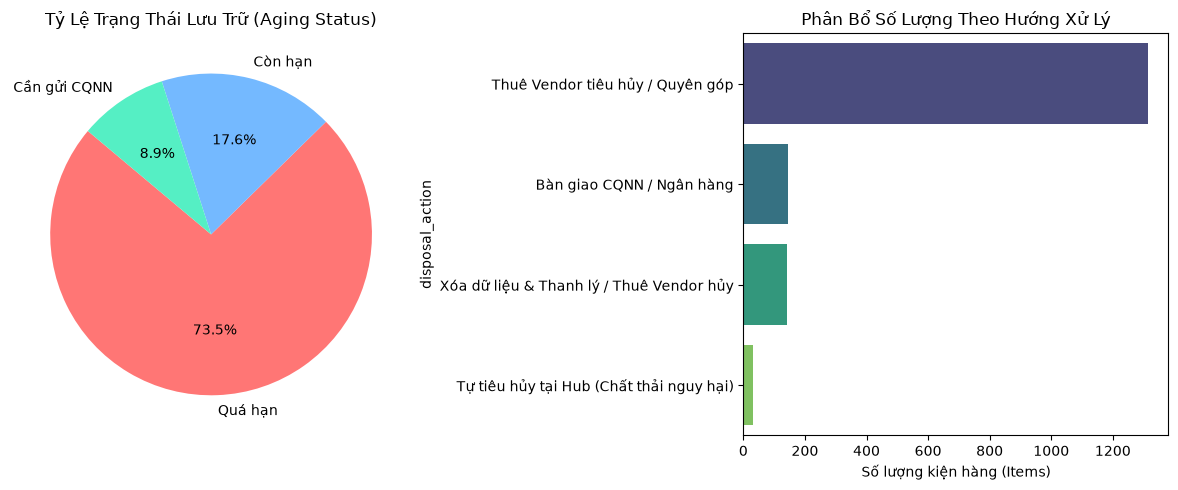

In [74]:
# tỷ trọng các hướng xử lý
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
status_counts = df_clean['aging_status'].value_counts()
colors = ['#ff7675', '#74b9ff', '#55efc4']
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Tỷ Lệ Trạng Thái Lưu Trữ (Aging Status)')

plt.subplot(1, 2, 2)
action_counts = df_clean['disposal_action'].value_counts()
sns.barplot(x=action_counts.values, y=action_counts.index, palette='viridis')
plt.title('Phân Bổ Số Lượng Theo Hướng Xử Lý')
plt.xlabel('Số lượng kiện hàng (Items)')

plt.tight_layout()
plt.show()


---
# PHẦN 3: KẾ HOẠCH TÁC CHIẾN XỬ LÝ DỨT ĐIỂM TRONG 7 NGÀY DƯƠNG LỊCH

### Mục tiêu & Ràng buộc:
- **Thời hạn**: Hoàn tất xử lý dứt điểm trong **7 ngày dương lịch (calendar days)**.
- **Nguồn lực**: Nhân sự kho và nhân viên đồng kiểm (COA + FPS + GE) có hạn.
- **Tổng khối lượng**: **1,635 kiện hàng**.

### Ma trận Ưu tiên (Priority Matrix):
1. **P1 — Khẩn cấp & Pháp lý cao (Day 1 - Day 2)**: Giấy tờ CQNN, Thẻ ATM, Tiền mặt -> Cần niêm phong và gửi công văn sang CQNN sớm nhất để kích hoạt đồng hồ 30 ngày phản hồi theo Luật.
2. **P2 — Giá trị cao & Rủi ro an ninh thông tin (Day 3)**: Thiết bị điện tử (Laptop, iPhone...) -> Cần nhân sự kỹ thuật xóa dữ liệu cá nhân, factory reset trước khi bàn giao.
3. **P3 — Hàng cồng kềnh giải phóng diện tích (Day 4 - Day 5)**: Hàng hóa hàng ngày tại Kho Lý Thường Kiệt & các Thùng/Bao lớn -> Chiếm 80% thể tích kho, cần phân loại theo tải trọng xe chở của Vendor.
4. **P4 — Đóng gói biên bản & Nghiệm thu (Day 6 - Day 7)**: Bàn giao xe Vendor, hoàn tất chữ ký Hội đồng xử lý 3 bên, cập nhật hệ thống.


In [75]:
# Capacity Planning
total_items = len(df_clean)
working_days_actual = 5 # 5 ngày đồng kiểm tập trung (Day 1 - Day 5), Day 6 bàn giao, Day 7 nghiệm thu
items_per_day_target = int(np.ceil(total_items / working_days_actual))

hours_per_day = 4 # Mỗi ngày dành 4 tiếng tập trung đồng kiểm tại kho
team_capacity_per_day = 50 * hours_per_day # 200 items / team / ngày

teams_needed = int(np.ceil(items_per_day_target / team_capacity_per_day))

capacity_plan = pd.DataFrame([
    {"Chỉ số vận hành": "Tổng số kiện hàng cần đồng kiểm", "Giá trị": f"{total_items:,} items"},
    {"Chỉ số vận hành": "Thời gian đồng kiểm thực địa", "Giá trị": f"{working_days_actual} ngày (Day 1 - Day 5)"},
    {"Chỉ số vận hành": "Khối lượng kiểm đếm bình quân / ngày", "Giá trị": f"{items_per_day_target:,} items / ngày"},
    {"Chỉ số vận hành": "Năng suất 1 cặp nhân sự (COA + FPS)", "Giá trị": f"{team_capacity_per_day:,} items / ca 4 tiếng"},
    {"Chỉ số vận hành": "Số tổ đồng kiểm cần bố trí", "Giá trị": f"{teams_needed} tổ (Gồm 4 nhân sự: 2 COA + 2 FPS/GE)"},
    {"Chỉ số vận hành": "Hệ số an toàn dự phòng rủi ro (Buffer)", "Giá trị": "20% thời gian mỗi ca để xử lý hàng ngoại lệ"}
])
capacity_plan


,Chỉ số vận hành,Giá trị
0,Tổng số kiện hàng cần đồng kiểm,"1,635 items"
1,Thời gian đồng kiểm thực địa,5 ngày (Day 1 - Day 5)
2,Khối lượng kiểm đếm bình quân / ngày,327 items / ngày
3,Năng suất 1 cặp nhân sự (COA + FPS),200 items / ca 4 tiếng
4,Số tổ đồng kiểm cần bố trí,2 tổ (Gồm 4 nhân sự: 2 COA + 2 FPS/GE)
5,Hệ số an toàn dự phòng rủi ro (Buffer),20% thời gian mỗi ca để xử lý hàng ngoại lệ


In [76]:
# 7-Day Execution Blueprint
cqnn_count = int((df_clean['aging_status'] == 'Cần gửi CQNN').sum())
electronics_count = int((df_clean['standard_category'] == 'Thiết bị điện tử có giá').sum())
vape_count = int((df_clean['standard_category'] == 'Thuốc lá điện tử').sum())
vendor_disposal_items = int((df_clean['disposal_action'] == 'Thuê Vendor tiêu hủy / Quyên góp').sum())

day1_items = vape_count + 119 # 31 vape + phân loại sơ bộ 119 items
day2_items = cqnn_count # 146 items CQNN & thẻ
day3_items = electronics_count # 143 items điện tử
day4_items = int(np.ceil(vendor_disposal_items / 2)) # 658 items tiêu dùng đợt 1
day5_items = vendor_disposal_items - day4_items # 657 items tiêu dùng đợt 2

schedule_7days = pd.DataFrame([
    {
        "Ngày": "Ngày 1 (T2)",
        "Nhiệm vụ trọng tâm": "Kick-off & Xử lý Hàng Nguy hại / Dễ hỏng",
        "Đối tượng xử lý chi tiết": f"Setup khu vực đồng kiểm tại Kho LTK; Phân loại & tiêu hủy ngay Thuốc lá điện tử ({vape_count} items) + Thực phẩm/Rượu còn tồn đọng; Sort nhanh theo Thùng/Bao.",
        "Khối lượng thực tế (Items)": day1_items,
        "Đầu ra / Artifact bàn giao": "Biên bản tiêu hủy hàng nguy hại nội bộ; Kho bãi được chia layout theo line xử lý.",
        "Nhân sự phụ trách (PIC)": "COA + FPS"
    },
    {
        "Ngày": "Ngày 2 (T3)",
        "Nhiệm vụ trọng tâm": "Đồng kiểm Nhóm Pháp lý & CQNN",
        "Đối tượng xử lý chi tiết": f"Kiểm đếm 100% Giấy tờ tùy thân (CCCD, CMND, GPLX), Thẻ ATM, Tiền mặt ({cqnn_count} items); Đối soát thông tin chủ sở hữu nếu có.",
        "Khối lượng thực tế (Items)": day2_items,
        "Đầu ra / Artifact bàn giao": "Niêm phong túi an toàn; Biên bản Phụ lục 4 (TTLT 18); Dự thảo Công văn gửi Công an / CQNN.",
        "Nhân sự phụ trách (PIC)": "COA + Legal + FPS"
    },
    {
        "Ngày": "Ngày 3 (T4)",
        "Nhiệm vụ trọng tâm": "Đồng kiểm Thiết bị Điện tử có giá",
        "Đối tượng xử lý chi tiết": f"Kiểm tra tình trạng kỹ thuật Điện thoại, Laptop, Sạc dự phòng, Tai nghe ({electronics_count} items); Xóa dữ liệu cá nhân, factory reset; Phân nhóm Thanh lý vs Tiêu hủy.",
        "Khối lượng thực tế (Items)": day3_items,
        "Đầu ra / Artifact bàn giao": "Biên bản Phụ lục 3 (TTLT 18); Danh mục thiết bị đề xuất thanh lý thu hồi chi phí.",
        "Nhân sự phụ trách (PIC)": "COA + GE + bộ phận IT"
    },
    {
        "Ngày": "Ngày 4 (T5)",
        "Nhiệm vụ trọng tâm": "Đồng kiểm Hàng tiêu dùng Đợt 1 (Kho LTK)",
        "Đối tượng xử lý chi tiết": "Đồng kiểm các lô hàng tiêu dùng, quần áo, mũ nón tại Kho Lý Thường Kiệt & các Bao lớn (Bao 1 - Bao 15). Đóng gói vào bao tải quy chuẩn.",
        "Khối lượng thực tế (Items)": day4_items,
        "Đầu ra / Artifact bàn giao": "Danh mục niêm phong đợt 1; Cân tổng trọng lượng phục vụ tính phí Vendor.",
        "Nhân sự phụ trách (PIC)": "Nhân sự Kho"
    },
    {
        "Ngày": "Ngày 5 (T6)",
        "Nhiệm vụ trọng tâm": "Đồng kiểm Hàng tiêu dùng Đợt 2 (Các Thùng lẻ)",
        "Đối tượng xử lý chi tiết": "Đồng kiểm toàn bộ các thùng lẻ còn lại (Thùng 01 - Thùng 30, Bì lẻ); Khử trùng dứt điểm danh sách tồn.",
        "Khối lượng thực tế (Items)": day5_items,
        "Đầu ra / Artifact bàn giao": "Hoàn tất 100% kiểm đếm vật lý; Bảng đối soát khớp 1:1 với Data.",
        "Nhân sự phụ trách (PIC)": "Nhân sự Kho"
    },
    {
        "Ngày": "Ngày 6 (T7)",
        "Nhiệm vụ trọng tâm": "Hội Đồng Phê Duyệt & Bàn Giao Vendor",
        "Đối tượng xử lý chi tiết": "Họp Hội đồng xử lý bưu gửi (GE + FPS + COA); Ký biên bản tổng Phụ lục 1; Xe Vendor đến bốc dỡ tiêu hủy dưới sự giám sát camera.",
        "Khối lượng thực tế (Items)": total_items,
        "Đầu ra / Artifact bàn giao": "Biên bản bàn giao rác thải công nghiệp có xác nhận của Vendor; Video/Ảnh nghiệm thu tiêu hủy.",
        "Nhân sự phụ trách (PIC)": "Hội đồng xử lý + Procurement"
    },
    {
        "Ngày": "Ngày 7 (CN)",
        "Nhiệm vụ trọng tâm": "Cập Nhật Hệ Thống & Nghiệm Thu Dự Án",
        "Đối tượng xử lý chi tiết": "Cập nhật trạng thái 'ĐÃ XỬ LÝ' lên Dashboard/DB; Dọn dẹp trả lại mặt bằng kho; Lập báo cáo kết quả gửi Ban Giám đốc.",
        "Khối lượng thực tế (Items)": 0,
        "Đầu ra / Artifact bàn giao": "Báo cáo hoàn thành dứt điểm đợt L&F; Dashboard nghiệm thu 100% Resolved.",
        "Nhân sự phụ trách (PIC)": "Lead & Team COA"
    }
])
display(schedule_7days)


,Ngày,Nhiệm vụ trọng tâm,Đối tượng xử lý chi tiết,Khối lượng thực tế (Items),Đầu ra / Artifact bàn giao,Nhân sự phụ trách (PIC)
0,Ngày 1 (T2),Kick-off & Xử lý Hàng Nguy hại / Dễ hỏng,Setup khu vực đồng kiểm tại Kho LTK; Phân loại & tiêu hủy ngay Thuốc lá điện tử (31 items) + Thự...,150,Biên bản tiêu hủy hàng nguy hại nội bộ; Kho bãi được chia layout theo line xử lý.,COA + FPS
1,Ngày 2 (T3),Đồng kiểm Nhóm Pháp lý & CQNN,"Kiểm đếm 100% Giấy tờ tùy thân (CCCD, CMND, GPLX), Thẻ ATM, Tiền mặt (146 items); Đối soát thông...",146,Niêm phong túi an toàn; Biên bản Phụ lục 4 (TTLT 18); Dự thảo Công văn gửi Công an / CQNN.,COA + Legal + FPS
2,Ngày 3 (T4),Đồng kiểm Thiết bị Điện tử có giá,"Kiểm tra tình trạng kỹ thuật Điện thoại, Laptop, Sạc dự phòng, Tai nghe (143 items); Xóa dữ liệu...",143,Biên bản Phụ lục 3 (TTLT 18); Danh mục thiết bị đề xuất thanh lý thu hồi chi phí.,COA + GE + bộ phận IT
3,Ngày 4 (T5),Đồng kiểm Hàng tiêu dùng Đợt 1 (Kho LTK),"Đồng kiểm các lô hàng tiêu dùng, quần áo, mũ nón tại Kho Lý Thường Kiệt & các Bao lớn (Bao 1 - B...",658,Danh mục niêm phong đợt 1; Cân tổng trọng lượng phục vụ tính phí Vendor.,Kho
4,Ngày 5 (T6),Đồng kiểm Hàng tiêu dùng Đợt 2 (Các Thùng lẻ),"Đồng kiểm toàn bộ các thùng lẻ còn lại (Thùng 01 - Thùng 30, Bì lẻ); Khử trùng dứt điểm danh sác...",657,Hoàn tất 100% kiểm đếm vật lý; Bảng đối soát khớp 1:1 với Data.,Kho
5,Ngày 6 (T7),Hội Đồng Phê Duyệt & Bàn Giao Vendor,Họp Hội đồng xử lý bưu gửi (GE + FPS + COA); Ký biên bản tổng Phụ lục 1; Xe Vendor đến bốc dỡ ti...,1635,Biên bản bàn giao rác thải công nghiệp có xác nhận của Vendor; Video/Ảnh nghiệm thu tiêu hủy.,Hội đồng xử lý + Procurement
6,Ngày 7 (CN),Cập Nhật Hệ Thống & Nghiệm Thu Dự Án,Cập nhật trạng thái 'ĐÃ XỬ LÝ' lên Dashboard/DB; Dọn dẹp trả lại mặt bằng kho; Lập báo cáo kết q...,0,Báo cáo hoàn thành dứt điểm đợt L&F; Dashboard nghiệm thu 100% Resolved.,Lead & Team COA


---
# PHẦN 4: STREAMLIT DASHBOARD THEO DÕI TIẾN ĐỘ & TÁI SỬ DỤNG

Để tối ưu hóa trải nghiệm giám sát vận hành thực tế cho Team COA và Ban Quản lý, toàn bộ phân hệ Dashboard đã được xây dựng thành một **Ứng dụng Web tương tác độc lập (Standalone Web App)** bằng thư viện **Streamlit** tại file [`app.py`](app.py).

### Lệnh Khởi Chạy Ứng Dụng (Run Command):
Mở terminal trong thư mục dự án và chạy lệnh sau:
```bash
streamlit run usecase/app.py
```
*(Ứng dụng sẽ tự động mở trên trình duyệt tại địa chỉ `http://localhost:8501`)*

---

### 5 Phân Hệ Tương Tác Vượt Trội Trên Streamlit App:
1. **Tab 1: Phân Tích & Phân Luồng**:
   - Donut Chart tỷ lệ Trạng thái lưu trữ (Quá hạn 73.5%, Còn hạn 17.6%, CQNN 8.9%).
   - Bar Chart phân bổ khối lượng theo từng Hướng xử lý nghiệp vụ.
   - Interactive Sunburst Hierarchy: Khám phá luồng tài sản từ *Dịch vụ* => *Loại hàng* => *Hướng xử lý* => *Trạng thái*.
   - Bản đồ Top 12 vị trí kho bãi chiếm nhiều diện tích nhất.
2. **Tab 2: 7-Day Execution Blueprint**:
   - Lộ trình chi tiết từng ngày từ Day 1 đến Day 7 với khối lượng items, PIC và Deliverables.
   - Interactive Checklist: Cho phép Tổ trưởng đồng kiểm tích chọn nghiệm thu trực tiếp theo thời gian thực.
3. **Tab 3: Tra Cứu Kiện Hàng & Xuất Dữ Liệu**:
   - Bảng tra cứu dữ liệu thời gian thực hỗ trợ sort, search, filter đa chiều.
   - Quick Filter 1-click cho các tài sản nhạy cảm: iPhone/IMEI, CCCD/CMND, Tiền mặt, Nồi chiên lớn, Thuốc y tế.
   - Nút tải dữ liệu đã lọc tức thì dưới 2 định dạng: **.CSV** và **.Excel (.xlsx)**.

---
# PHẦN 5: CẢI TIẾN QUY TRÌNH & ĐỀ XUẤT TỰ ĐỘNG HÓA (BONUS)


### 1. Tách Cột "Ghi Chú Xử Lý" & "Chi Tiết Vật Phẩm" Ra Khỏi Tên Hàng
- **Thực trạng**: Tên hàng hiện tại chứa lẫn lộn: Gần như mọi vấn đề dữ liệu đều đến từ việc nhập tay vào Excel.
- **Giải pháp**: Xây dựng form nhập chuẩn có data validation hoặc integrate AI để validate và phân loại data input:
  - Dịch vụ, loại hàng, trạng thái chủ sở hữu là dropdown.
  - Vị trí kho tách thành 3 cột: Bao/Thùng, Bì, Lẻ. Hiện có hơn 130 cách viết cho cùng một vị trí.
  - Mã booking bắt buộc nhập. Thiếu cột này là lý do phải dùng ticket làm đại diện cho "chủ hàng".
  - Ngày nhập theo định dạng cố định (ISO), cột kiểu ngày, không gõ text. Việc này chặn lỗi đảo dd/mm ngay từ gốc.
  - Mỗi món một dòng, có cột số lượng riêng (hiện 269 dòng ghi nhiều món trong một ô).
  - Mã định danh duy nhất cho mỗi món. ID hiện tại dùng chung cho nhiều món khác nhau nên không thể làm unique key.

### 2. Hệ Thống Cảnh Báo Sớm Hạn Lưu Trữ
- **Thực trạng**: Hàng hóa bị dồn ứ từ năm 2020 đến 2023 mới đem ra xử lý một lần, gây quá tải kho và rủi ro pháp lý.
- **Giải pháp**: Tích hợp Bot Slack app cảnh báo tự động trên Slack/Email:
  - **Với GBC**: Cảnh báo tại ngày **T+20** (còn 10 ngày hết hạn) để nhân viên liên hệ khách lần cuối.
  - **Với GE**: Cảnh báo tại ngày **T+75** (sắp hết hạn công khai 3 tháng) và ngày **T+150** (chuẩn bị lập Hội đồng xử lý tiêu hủy T+180).
  - **Tác động**: Xử lý gối đầu theo từng tháng (FIFO), triệt tiêu hoàn toàn tình trạng tồn kho đa năm.

### 3. Thiết Lập Bộ Chỉ Số KPI Vận Hành & Giám Sát Tồn Đọng (L&F Health Metrics)
- `Aging Index`: Tỷ lệ hàng lưu kho > 30 ngày đối với GBC và > 180 ngày đối với GE (Mục tiêu: < 5%).
- `Disposal Cycle Time`: Thời gian từ lúc hết hạn đến khi hoàn tất tiêu hủy (Mục tiêu: < 7 ngày làm việc).
- `Data Integrity Rate`: Tỷ lệ bản ghi có đầy đủ Ticket, Ngày và Phân loại hợp lệ (Mục tiêu: 100%).

In [77]:
# Template Nhập Liệu Chuẩn Hóa Phục Vụ Tự Động Hóa Cho Sau Này
template_columns_spec = pd.DataFrame([
    {
        "Tên cột chuẩn (Standard Field)": "item_id",
        "Kiểu dữ liệu (Data Type)": "Varchar (Auto-generated)",
        "Quy tắc hợp lệ (Validation Rules)": "Bắt buộc duy nhất; format: LF-HCM-YYYYMM-XXXXX.",
        "Mục đích & Lợi ích": "Tránh trùng lặp ID, loại bỏ tình trạng ID 'không có' hay dùng chung ID giữ chỗ."
    },
    {
        "Tên cột chuẩn (Standard Field)": "intake_date",
        "Kiểu dữ liệu (Data Type)": "Date (YYYY-MM-DD)",
        "Quy tắc hợp lệ (Validation Rules)": "Bắt buộc; Ngày tiếp nhận <= Ngày hiện tại.",
        "Mục đích & Lợi ích": "Chuẩn hóa định dạng ngày, triệt tiêu lỗi #REF! và lỗi đảo lộn ngày/tháng."
    },
    {
        "Tên cột chuẩn (Standard Field)": "service_type",
        "Kiểu dữ liệu (Data Type)": "Dropdown (Enum)",
        "Quy tắc hợp lệ (Validation Rules)": "Chỉ chọn: ['Express', 'Bike', 'Car', 'Food', 'Mart'].",
        "Mục đích & Lợi ích": "Ngăn chặn nhập sai tên dịch vụ; tự động áp dụng SLA tương ứng."
    },
    {
        "Tên cột chuẩn (Standard Field)": "ticket_id",
        "Kiểu dữ liệu (Data Type)": "String",
        "Quy tắc hợp lệ (Validation Rules)": "Bắt buộc nếu dịch vụ là Express; Khuyến khích với Bike/Car.",
        "Mục đích & Lợi ích": "Truy vết cuốc xe và chủ sở hữu trên hệ thống Help Center."
    },
    {
        "Tên cột chuẩn (Standard Field)": "category",
        "Kiểu dữ liệu (Data Type)": "Dropdown (Enum)",
        "Quy tắc hợp lệ (Validation Rules)": "Danh mục 5 nhóm chuẩn (Điện tử, CQNN/Thẻ, Tiêu dùng, Nguy hại, Thực phẩm).",
        "Mục đích & Lợi ích": "Không cho nhập tự do; map trực tiếp ra hình thức xử lý pháp lý."
    },
    {
        "Tên cột chuẩn (Standard Field)": "item_name",
        "Kiểu dữ liệu (Data Type)": "Text (Văn bản ngắn)",
        "Quy tắc hợp lệ (Validation Rules)": "Chỉ mô tả vật phẩm chính (ví dụ: 'Áo khoác gió')",
        "Mục đích & Lợi ích": "Giữ tên hàng gọn gàng, phục vụ tìm kiếm nhanh."
    },
    {
        "Tên cột chuẩn (Standard Field)": "item_details_and_notes",
        "Kiểu dữ liệu (Data Type)": "Text (Ghi chú chi tiết)",
        "Quy tắc hợp lệ (Validation Rules)": "Tách riêng tình trạng (hỏng/mới), HSD, thương hiệu, IMEI.",
        "Mục đích & Lợi ích": "Tách ghi chú xử lý ra khỏi tên hàng (giải quyết triệt để yêu cầu Phần 4)."
    },
    {
        "Tên cột chuẩn (Standard Field)": "warehouse_location",
        "Kiểu dữ liệu (Data Type)": "Dropdown theo Barcode",
        "Quy tắc hợp lệ (Validation Rules)": "Mã hóa vị trí: KHO-DAY-KE-THUNG (Ví dụ: LTK-A1-02-B05).",
        "Mục đích & Lợi ích": "Quản lý vị trí chính xác đến từng kệ, không nhập văn bản tự do."
    }
])
display(template_columns_spec)


,Tên cột chuẩn (Standard Field),Kiểu dữ liệu (Data Type),Quy tắc hợp lệ (Validation Rules),Mục đích & Lợi ích
0,item_id,Varchar (Auto-generated),Bắt buộc duy nhất; format: LF-HCM-YYYYMM-XXXXX.,"Tránh trùng lặp ID, loại bỏ tình trạng ID 'không có' hay dùng chung ID giữ chỗ."
1,intake_date,Date (YYYY-MM-DD),Bắt buộc; Ngày tiếp nhận <= Ngày hiện tại.,"Chuẩn hóa định dạng ngày, triệt tiêu lỗi #REF! và lỗi đảo lộn ngày/tháng."
2,service_type,Dropdown (Enum),"Chỉ chọn: ['Express', 'Bike', 'Car', 'Food', 'Mart'].",Ngăn chặn nhập sai tên dịch vụ; tự động áp dụng SLA tương ứng.
3,ticket_id,String,Bắt buộc nếu dịch vụ là Express; Khuyến khích với Bike/Car.,Truy vết cuốc xe và chủ sở hữu trên hệ thống Help Center.
4,category,Dropdown (Enum),"Danh mục 5 nhóm chuẩn (Điện tử, CQNN/Thẻ, Tiêu dùng, Nguy hại, Thực phẩm).",Không cho nhập tự do; map trực tiếp ra hình thức xử lý pháp lý.
5,item_name,Text (Văn bản ngắn),Chỉ mô tả vật phẩm chính (ví dụ: 'Áo khoác gió'),"Giữ tên hàng gọn gàng, phục vụ tìm kiếm nhanh."
6,item_details_and_notes,Text (Ghi chú chi tiết),"Tách riêng tình trạng (hỏng/mới), HSD, thương hiệu, IMEI.",Tách ghi chú xử lý ra khỏi tên hàng (giải quyết triệt để yêu cầu Phần 4).
7,warehouse_location,Dropdown theo Barcode,Mã hóa vị trí: KHO-DAY-KE-THUNG (Ví dụ: LTK-A1-02-B05).,"Quản lý vị trí chính xác đến từng kệ, không nhập văn bản tự do."


In [ ]:
# Xuất file dữ liệu sạch đã phân loại để các bên sử dụng
output_csv_path = 'cleaned_data.csv'
if os.path.exists('usecase'):
    output_csv_path = os.path.join('usecase', output_csv_path)

df_clean.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
print(f"File dữ liệu sạch được lưu tại: '{output_csv_path}'")

File dữ liệu sạch được lưu tại: 'cleaned_lost_and_found_hcm.csv'
